In [ ]:
import pandas as pd
import sys 
import os
from rerankers import Reranker
from beir.datasets.data_loader import GenericDataLoader
from beir.retrieval.evaluation import EvaluateRetrieval
sys.path.append("../..")
from utils.cs_pipeline import GraphCS
from utils.similarity_search_pipeline import Search
from utils.reranking import (evaluate,
                             perform_postprocessing_and_update_results,
                             convert_to_beir_evaluation)
import networkit as nk
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import warnings
warnings.filterwarnings("ignore")

API_KEY = os.environ.get("ES_API_KEY")

In [3]:
SearchEngine = Search(
    host = "https://localhost:9200/",
    api_key=API_KEY,
    verify=False, 
    index="dbpedia_v3", 
    vector_index="dbpedia_vector_index_v3", 
    embedding_model="sentence-transformers/multi-qa-mpnet-base-cos-v1"
    )

node_df = pd.read_parquet("../../03_data/preprocessed_data/nodes_beir_dbpedia.parquet")
rel_df = pd.read_parquet('../../03_data/preprocessed_data/pagelink_edges_beir_dbpedia.parquet')

ranker = Reranker('mixedbread-ai/mxbai-rerank-base-v1', 
                  model_type='cross-encoder')
Graph = GraphCS(node_df, 
                rel_df)
evaluator = EvaluateRetrieval()

corpus, queries, qrels = GenericDataLoader(data_folder="../../03_data/raw_data/beir_dbpedia/dbpedia-entity").load(split="test")

Loading TransformerRanker model mixedbread-ai/mxbai-rerank-base-v1 (this message can be suppressed by setting verbose=0)
No device set
Using device cuda
No dtype set
Using dtype torch.float32
Loaded model mixedbread-ai/mxbai-rerank-base-v1
Using device cuda.
Using dtype torch.float32.
Building Graph from given Data...
Graph built


  0%|          | 0/4635922 [00:00<?, ?it/s]

# BM25 Retrieval and CS:

In [57]:
to_evaluate = "SemSearch_LS-34"
print(queries[to_evaluate])
res_vec = SearchEngine.perform_similarity_search_vector(search_string=queries[to_evaluate], n_results=100, return_objects=["dbpedia_id"])
res_cs = Graph.execute_community_search(search_nodes=res_vec["dbpedia_id"][:10] , method="LFMLocal", alpha=1.0)
result_list = Graph._convert_dbpedia_to_index(res_cs)
len(res_cs)

ratt albums


54

# Density

In [51]:
def calculate_community_density(graph, community_nodes):
    """
    Berechnet die Dichte einer Community in einem Graphen.
    
    Parameters:
        graph (nk.graph.Graph): Der Graph, in dem die Community definiert ist.
        community_nodes (list): Liste von Knoten, die zur Community gehören.
    
    Returns:
        float: Die Dichte der Community.
    """
    # Subgraph für die Community erstellen
    subgraph = nk.graphtools.subgraphAndNeighborsFromNodes(graph, community_nodes, includeOutNeighbors=False)

    # Anzahl der Kanten und Knoten in der Community
    num_edges = subgraph.numberOfEdges()
    num_nodes = subgraph.numberOfNodes()

    # Dichte berechnen: 2E / (n * (n - 1))
    if num_nodes <= 1:
        return 0  # Keine sinnvolle Dichte für leere oder einzelne Knoten

    density = (2 * num_edges) / (num_nodes * (num_nodes - 1))
    return density

In [58]:
print("CS-Density", calculate_community_density(Graph.G, result_list))
print("Vector Density", calculate_community_density(Graph.G, Graph._convert_dbpedia_to_index(res_vec["dbpedia_id"])))

CS-Density 0.1914744933612858
Vector Density 0.025656565656565655


# Plots

In [ ]:
def get_node_colors(res, qrels):
    colors = []
    for item in res:
        if item not in qrels.keys() or qrels[item] == 0:
            colors.append("lightgrey")
            continue
        if qrels[item] == 1:
            colors.append("darkgrey")
        elif qrels[item] == 2:
            colors.append("dimgrey")
    return colors

def get_labels(G, node_df):
    labels = {}
    for node in G.iterNodes():
        labels[node] = node_df[node_df.index == node].title.values[0]
    return labels

def get_relevant_labels(G, node_df, qrels):
    labels = {}
    for node in G.iterNodes():
        if Graph.item_to_index[node] in qrels.keys():
            if qrels[Graph.item_to_index[node]] > 0:
                labels[node] = node_df[node_df.index == node].title.values[0]
    return labels

In [6]:
lightgrey_patch = mpatches.Patch(color='lightgrey', label='irrelevant')
darkgrey_patch = mpatches.Patch(color='darkgrey', label='relevant')
dimgrey_patch = mpatches.Patch(color='dimgrey', label='sehr relevant')

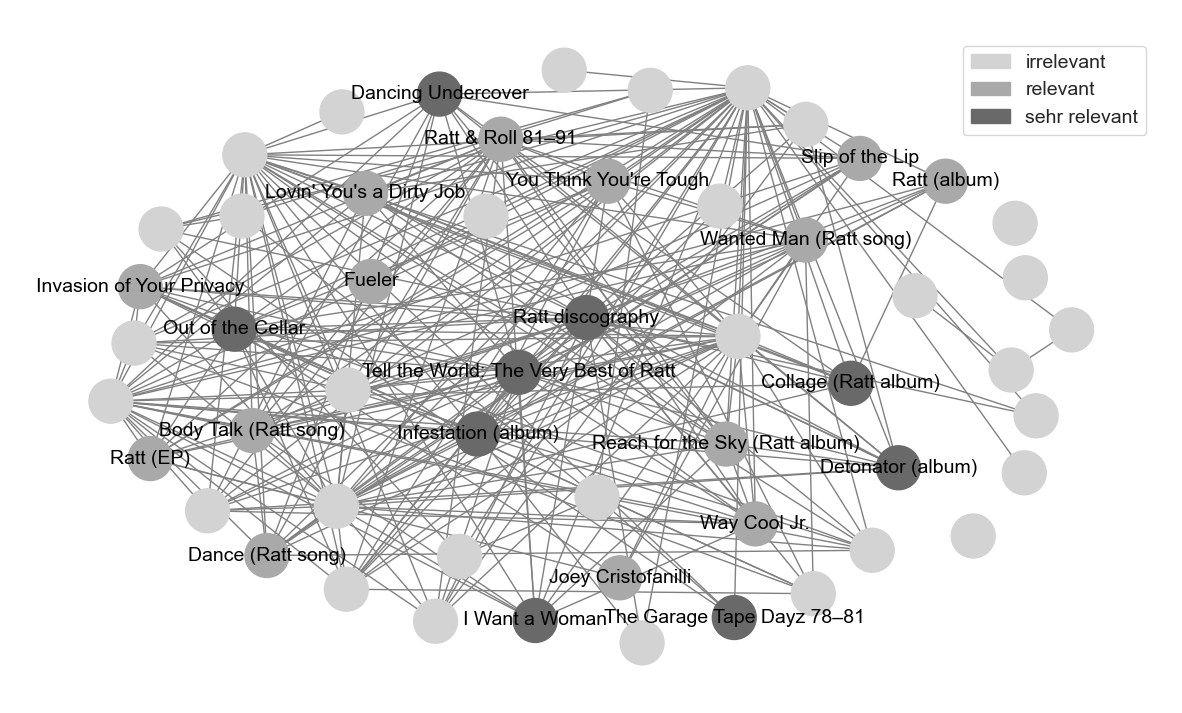

In [ ]:
#Abbildung 20 
subG = nk.graphtools.subgraphAndNeighborsFromNodes(Graph.G, result_list, includeOutNeighbors=False)
nxG = nk.nxadapter.nk2nx(subG)
plt.figure(figsize=(15, 9))
nx.draw_networkx(nxG,
                 pos=nx.arf_layout(nxG), 
                 labels = get_relevant_labels(subG, node_df, qrels[to_evaluate]), 
                 node_color =get_node_colors([Graph.item_to_index[item] for item in list(nxG.nodes)], qrels= qrels[to_evaluate]),
                 font_size=14, 
                 node_size=1000, 
                 font_color='black',
                 edge_color='grey')
plt.legend(handles=[lightgrey_patch, darkgrey_patch, dimgrey_patch], loc=(0.82, 0.82), fontsize=14)
limits = plt.axis('off')
plt.savefig("Abbildung_20.svg")
plt.show()

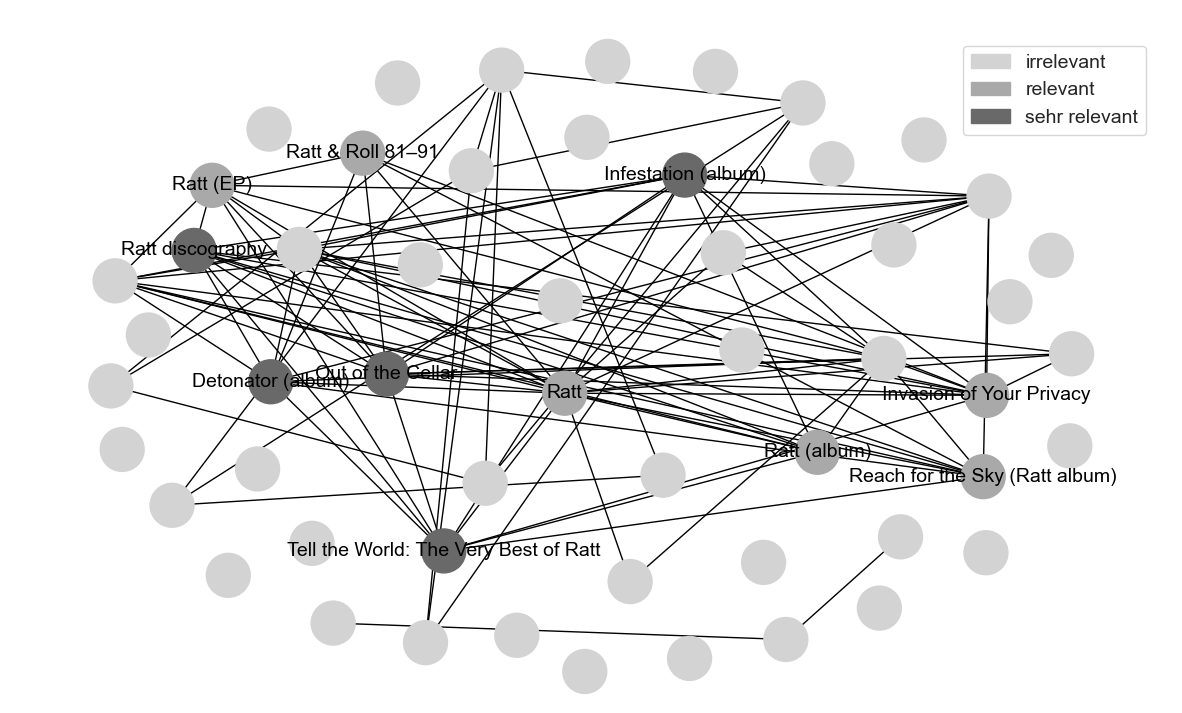

In [ ]:
#Abbildung 19
subG = nk.graphtools.subgraphAndNeighborsFromNodes(Graph.G, Graph._convert_dbpedia_to_index(res_vec["dbpedia_id"][:len(res_cs)]), includeOutNeighbors=False)
nxG = nk.nxadapter.nk2nx(subG)
plt.figure(figsize=(15, 9))
nx.draw_networkx(nxG,
                 pos=nx.arf_layout(nxG), 
                 labels = get_relevant_labels(subG, node_df, qrels[to_evaluate]), 
                 node_color =get_node_colors([Graph.item_to_index[item] for item in list(nxG.nodes)], qrels= qrels[to_evaluate]),
                 font_size=14, 
                 node_size=1000, 
                 font_color='black')
plt.legend(handles=[lightgrey_patch, darkgrey_patch, dimgrey_patch], loc=(0.82, 0.82), fontsize=14)
limits = plt.axis('off')
plt.savefig("Abbildung_19.svg")
plt.show()

In [59]:
# Get overlapping nodes:
overlap = set(res_vec["dbpedia_id"][:len(res_cs)]) & set(res_cs)
print(f"Overlap: {len(overlap)}")

Overlap: 20


In [ ]:
# Get relevances of initial nodes
for item in qrels[to_evaluate]:
    if item in res_vec["dbpedia_id"][:10]:
        print(item, qrels[to_evaluate][item])


<dbpedia:Infestation_(album)> 2
<dbpedia:Ratt:_The_Video> 0
<dbpedia:Ratt_&_Roll_81–91> 1
<dbpedia:Ratt_(EP)> 1
<dbpedia:Ratt_(album)> 1
<dbpedia:Ratt_discography> 2
<dbpedia:Tell_the_World:_The_Very_Best_of_Ratt> 2


In [ ]:
# Get relevances in initial IR
for item in qrels[to_evaluate]:
    if item in res_vec["dbpedia_id"][:54]:
        print(item, qrels[to_evaluate][item])
# 5 very relevant
# 5 relevant

<dbpedia:Detonator_(album)> 2
<dbpedia:Infestation_(album)> 2
<dbpedia:Invasion_of_Your_Privacy> 1
<dbpedia:Out_of_the_Cellar> 2
<dbpedia:Pre-Ratt_Days> 0
<dbpedia:Ratt:_The_Video> 0
<dbpedia:Ratt> 1
<dbpedia:Ratt_&_Roll_81–91> 1
<dbpedia:Ratt_(EP)> 1
<dbpedia:Ratt_(album)> 1
<dbpedia:Ratt_discography> 2
<dbpedia:Rattus_Erectus_1976–1982> 0
<dbpedia:Reach_for_the_Sky_(Ratt_album)> 1
<dbpedia:Robbin_Crosby> 0
<dbpedia:Stephen_Pearcy> 0
<dbpedia:Tell_the_World:_The_Very_Best_of_Ratt> 2
<dbpedia:Warren_DeMartini> 0


In [ ]:
# Get relevances in CS
for item in qrels[to_evaluate]:
    if item in res_cs:
        if qrels[to_evaluate][item] > 0:
            print(item, qrels[to_evaluate][item])
# 9 very relevant
# 14 relevant

<dbpedia:Body_Talk_(Ratt_song)> 1
<dbpedia:Collage_(Ratt_album)> 2
<dbpedia:Dance_(Ratt_song)> 1
<dbpedia:Dancing_Undercover> 2
<dbpedia:Detonator_(album)> 2
<dbpedia:Fueler> 1
<dbpedia:I_Want_a_Woman> 2
<dbpedia:Infestation_(album)> 2
<dbpedia:Invasion_of_Your_Privacy> 1
<dbpedia:Joey_Cristofanilli> 1
<dbpedia:Lovin'_You's_a_Dirty_Job> 1
<dbpedia:Out_of_the_Cellar> 2
<dbpedia:Ratt_&_Roll_81–91> 1
<dbpedia:Ratt_(EP)> 1
<dbpedia:Ratt_(album)> 1
<dbpedia:Ratt_discography> 2
<dbpedia:Reach_for_the_Sky_(Ratt_album)> 1
<dbpedia:Slip_of_the_Lip> 1
<dbpedia:Tell_the_World:_The_Very_Best_of_Ratt> 2
<dbpedia:The_Garage_Tape_Dayz_78–81> 2
<dbpedia:Wanted_Man_(Ratt_song)> 1
<dbpedia:Way_Cool_Jr.> 1
<dbpedia:You_Think_You're_Tough> 1


# Berechnung Conductance

In [70]:
# CS
nk.scd.SetConductance(Graph.G, result_list).run().getConductance()

0.6204986149584487

In [71]:
# Vector
nk.scd.SetConductance(Graph.G, Graph._convert_dbpedia_to_index(res_vec["dbpedia_id"][:len(res_cs)])).run().getConductance()

0.907177033492823

# Kohärenz in der Community

In [72]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def calculate_content_coherence(model_name, node_contents):
    """
    Berechnet die Kohärenz der Inhalte einer Community.
    
    Parameters:
        node_contents (list of str): Liste von Texten/Inhalten der Knoten in der Community.
    
    Returns:
        float: Durchschnittliche Kosinusähnlichkeit zwischen den Knoteninhalten (Kohärenz).
    """
    # SentenceTransformer-Modell laden
    model = SentenceTransformer(model_name)

    # Embeddings für die Knoteninhalte berechnen
    embeddings = model.encode(node_contents, convert_to_tensor=False)

    # Kosinusähnlichkeit zwischen allen Knotenpaaren berechnen
    similarity_matrix = cosine_similarity(embeddings)
    
    # Nur obere Dreiecksmatrix (ohne Diagonale) für Paarvergleiche verwenden
    n = len(node_contents)
    upper_triangle_indices = np.triu_indices(n, k=1)
    similarities = similarity_matrix[upper_triangle_indices]

    # Durchschnittliche Ähnlichkeit berechnen
    if len(similarities) == 0:
        return 0  # Keine Paare vorhanden

    average_similarity = np.mean(similarities)
    return average_similarity

In [73]:
# CS
calculate_content_coherence("sentence-transformers/multi-qa-mpnet-base-cos-v1", node_df[node_df.id.isin(res_cs)].text.to_list())

0.33741355

In [ ]:
# Vector
calculate_content_coherence("sentence-transformers/multi-qa-mpnet-base-cos-v1", node_df[node_df.id.isin(res_vec["dbpedia_id"][:len(res_cs)])].text.to_list())

0.42725956

In [213]:
# Random Community
import random
from sklearn.model_selection import KFold

def cross_validation_coherence(node_contents, k=5):
    """
    Führt eine k-fache Kreuzvalidierung zur Kohärenzbewertung durch.
    Parameters:
        node_contents (list of str): Liste von Texten/Inhalten der Knoten.
        k (int): Anzahl der Folds für die Kreuzvalidierung.
    Returns:
        list: Kohärenzwerte für jeden Fold.
    """
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    coherence_scores = []

    for train_index, test_index in kf.split(node_contents):
        train_contents = [node_contents[i] for i in train_index]
        coherence = calculate_content_coherence("sentence-transformers/multi-qa-mpnet-base-cos-v1",train_contents)
        coherence_scores.append(coherence)

    return coherence_scores

def select_random_nodes(node_contents, sample_size):
    """
    Wählt zufällige Knoten aus einem Datensatz.
    Parameters:
        node_contents (list of str): Liste von Texten/Inhalten der Knoten.
        sample_size (int): Anzahl der zufällig ausgewählten Knoten.
    Returns:
        list: Zufällig ausgewählte Knoteninhalte.
    """
    return random.sample(node_contents, sample_size)

In [225]:
# Parameter
num_samples = 10  # Anzahl der Stichproben
sample_size = 70   # Anzahl der Knoten pro Stichprobe
k = 5            # Anzahl der Folds für die Kreuzvalidierun
all_coherence_scores = []

for sample_index in range(num_samples):
    print(f"\nSample {sample_index + 1}:")

    # Zufällige Knoten auswählen
    selected_nodes = select_random_nodes(node_df.text.to_list(), sample_size)

    # Kohärenz für die Stichprobe berechnen
    coherence = calculate_content_coherence("sentence-transformers/multi-qa-mpnet-base-cos-v1",selected_nodes)
    print(f"Kohärenz der ausgewählten Knoten: {coherence:.4f}")

        # Kreuzvalidierung durchführen
    coherence_scores = cross_validation_coherence(selected_nodes, k)
    all_coherence_scores.append(coherence_scores)

    print(f"Kohärenzwerte aus {k}-facher Kreuzvalidierung:")
    for i, score in enumerate(coherence_scores):
        print(f"  Fold {i + 1}: {score:.4f}")
    print(f"Durchschnittliche Kohärenz: {np.mean(coherence_scores):.4f}")
    print(f"Standardabweichung: {np.std(coherence_scores):.4f}")

    # Zusammenfassung über alle Stichproben
print("\nZusammenfassung über alle Samples:")
overall_mean = np.mean([np.mean(scores) for scores in all_coherence_scores])
overall_std = np.std([np.mean(scores) for scores in all_coherence_scores])
print(f"Gesamtdurchschnittliche Kohärenz: {overall_mean:.4f}")
print(f"Gesamtstandardabweichung: {overall_std:.4f}")


Sample 1:
Kohärenz der ausgewählten Knoten: 0.0534
Kohärenzwerte aus 5-facher Kreuzvalidierung:
  Fold 1: 0.0546
  Fold 2: 0.0534
  Fold 3: 0.0532
  Fold 4: 0.0522
  Fold 5: 0.0517
Durchschnittliche Kohärenz: 0.0530
Standardabweichung: 0.0010

Sample 2:
Kohärenz der ausgewählten Knoten: 0.0559
Kohärenzwerte aus 5-facher Kreuzvalidierung:
  Fold 1: 0.0558
  Fold 2: 0.0549
  Fold 3: 0.0541
  Fold 4: 0.0518
  Fold 5: 0.0625
Durchschnittliche Kohärenz: 0.0558
Standardabweichung: 0.0036

Sample 3:
Kohärenz der ausgewählten Knoten: 0.0553
Kohärenzwerte aus 5-facher Kreuzvalidierung:
  Fold 1: 0.0507
  Fold 2: 0.0561
  Fold 3: 0.0547
  Fold 4: 0.0581
  Fold 5: 0.0563
Durchschnittliche Kohärenz: 0.0552
Standardabweichung: 0.0025

Sample 4:
Kohärenz der ausgewählten Knoten: 0.0594
Kohärenzwerte aus 5-facher Kreuzvalidierung:
  Fold 1: 0.0571
  Fold 2: 0.0639
  Fold 3: 0.0614
  Fold 4: 0.0611
  Fold 5: 0.0540
Durchschnittliche Kohärenz: 0.0595
Standardabweichung: 0.0035

Sample 5:
Kohärenz der 

# Reranking

In [78]:
def reranking(corpus: pd.DataFrame, ranker: Reranker, query: tuple[(str, str)], to_be_reranked:list[str]) -> dict[dict[str,float]]:
    """
    This function reranks the documents for a given query.
    Parameters:
    corpus: the complete corpus to get relevant text passages
    ranker: rerankers object
    query: the query to rerank for
    to_be_reranked: list of documents to rerank
    """
    reranked_scores = {}
    relevant_corpus = corpus[corpus["id"].isin(to_be_reranked)]
    reranked = ranker.rank(query=query, 
                           docs=relevant_corpus.text.to_list(), 
                           doc_ids=relevant_corpus.id.to_list())
    for doc in range(len(reranked.results)):
        reranked_scores[reranked.results[doc].document.doc_id] = reranked.results[doc].score
    return reranked_scores

In [ ]:
# Tabelle 4
# With CS reranked
res, res_qrel={},{}
res[to_evaluate] = reranking(node_df,ranker, queries[to_evaluate],res_cs)
res_qrel[to_evaluate] = qrels[to_evaluate] 
evaluator.evaluate(results=res ,k_values=[10,100], qrels=res_qrel)


({'NDCG@10': 0.7853, 'NDCG@100': 0.8895},
 {'MAP@10': 0.356, 'MAP@100': 0.79019},
 {'Recall@10': 0.36, 'Recall@100': 0.92},
 {'P@10': 0.9, 'P@100': 0.23})

In [ ]:
# Tabelle 4
# Vector reranked
res, res_qrel={},{}
res[to_evaluate] = reranking(node_df,ranker, queries[to_evaluate], res_vec["dbpedia_id"][:len(res_cs)])
res_qrel[to_evaluate] = qrels[to_evaluate]
evaluator.evaluate(results=res ,k_values=[10,100], qrels=res_qrel)

({'NDCG@10': 0.7795, 'NDCG@100': 0.59741},
 {'MAP@10': 0.36, 'MAP@100': 0.43021},
 {'Recall@10': 0.36, 'Recall@100': 0.44},
 {'P@10': 0.9, 'P@100': 0.11})

In [ ]:
# Tabelle 4
# Basic Vector Score
res, res_qrel, reres={},{},{}
for item, score in zip(res_vec["dbpedia_id"][:len(res_cs)], res_vec["score"][:len(res_cs)]):
    reres[item] = score
res[to_evaluate] = reres
res_qrel[to_evaluate] = qrels[to_evaluate]
evaluator.evaluate(results=res ,k_values=[10,100], qrels=res_qrel)

({'NDCG@10': 0.44573, 'NDCG@100': 0.44094},
 {'MAP@10': 0.17257, 'MAP@100': 0.24719},
 {'Recall@10': 0.24, 'Recall@100': 0.44},
 {'P@10': 0.6, 'P@100': 0.11})